# ENVS 407 - Snow Hydrology 
## Snowpack Water (Mass) Balance Problem 

* Solving the in class snowpack water balance problem in python

created by Cassie Lumbrazo\
last updated: March 2026

In [2]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib 
import matplotlib.pyplot as plt

# data packages 
import pandas as pd
import numpy as np

__________________________

# Snowpack Water Balance

We calculate the change in snow water equivalent (SWE) using the snowpack mass balance equation from the textbook.

### Snow Water Balance (Eq. 9.1)

$$
\Delta SWE = P \pm E \pm O
$$

where

- $P$ = precipitation input (snowfall)
- $E$ = evaporation or sublimation from the snowpack
- $O$ = outputs from the snowpack (snowmelt runoff)

The final SWE at the end of the period is

$$
SWE_{final} = SWE_{initial} + P - E - O
$$

All values are expressed in **meters of water equivalent**.

In [3]:
# --------------------------------------------------
# Given Measurements from the Problem
# --------------------------------------------------

# Initial snowpack
initial_depth_cm = 137          # cm snow depth
snow_density = 310              # kg/m3 average snow density

# Snowfall during February
snowfall_cm = 112               # cm snowfall
new_snow_density = 100          # kg/m3 density of new snowfall

# Energy flux causing sublimation
latent_heat_flux = -12          # W/m2 (negative indicates loss)

# Snowmelt runoff
snowmelt_mm = 28                # mm water leaving snowpack

# Watershed size
watershed_area_km2 = 36         # km2

In [ ]:
# --------------------------------------------------
# Physical Constants
# --------------------------------------------------

rho_water = 1000      # kg/m3 density of liquid water
rho_ice = 917         # kg/m3 density of ice
rho_air = 1.25        # kg/m3 density of air

cp_water = 4.2e3      # J/kg/C specific heat of water
cp_ice = 2.0e3        # J/kg/C specific heat of ice
cp_air = 1.0e3        # J/kg/C specific heat of air

Lf = 3.34e5           # J/kg latent heat of fusion
Lv = 2.5e6            # J/kg latent heat of vaporization
Ls = 2.8e6            # J/kg latent heat of sublimation

g = 9.8               # m/s2 gravitational acceleration

__________________________

## Step 1 — Initial Snow Water Equivalent

Snow water equivalent is calculated as

$$
SWE = h \times \frac{\rho_s}{\rho_w}
$$

where

- $h$ = snow depth
- $\rho_s$ = snow density
- $\rho_w$ = density of water

For the initial snowpack:

- snow depth = 137 cm
- snow density = 310 kg / m³
- water density = 1000 kg / m³

In [5]:
# Convert snow depth to meters
initial_depth_m = initial_depth_cm / 100

# Calculate SWE
SWE_initial = initial_depth_m * (snow_density / rho_water)

print(f"Initial SWE = {SWE_initial:.3f} m")

Initial SWE = 0.425 m


__________________________

## Step 2 — Snowfall Contribution

Snowfall adds mass to the snowpack.

The snowfall SWE contribution is calculated as

$$
P = h_{snowfall} \times \frac{\rho_{new}}{\rho_w}
$$

where

- $h_{snowfall}$ = snowfall depth
- $\rho_{new}$ = density of new snow
- $\rho_w$ = density of water

Given:

- snowfall depth = 112 cm
- new snow density = 100 kg / m³

In [6]:
# Convert snowfall depth
snowfall_m = snowfall_cm / 100

# SWE contribution from snowfall
P = snowfall_m * (new_snow_density / rho_water)

print(f"Snowfall SWE contribution (P) = {P:.3f} m")

Snowfall SWE contribution (P) = 0.112 m


__________________________

## Step 3 — Sublimation Loss

The latent heat flux can be converted to a mass flux using

$$
\dot{m} = \frac{Q_e}{L_s}
$$

where

- $Q_e$ = latent heat flux
- $L_s$ = latent heat of sublimation

Because

$$
1\ \text{kg m}^{-2} = 1\ \text{mm SWE}
$$

the resulting mass loss can be converted directly to **water equivalent**.

The flux is integrated over the full month of February:

$$
t = 28 \times 86400 \ \text{seconds}
$$

In [7]:
# Seconds in February (28 days)
seconds_february = 28 * 24 * 3600

# Mass loss rate
mass_flux = latent_heat_flux / Ls  # kg/m2/s

# Convert to SWE change
E_mm = mass_flux * seconds_february   # mm water equivalent
E_m = E_mm / 1000                     # convert mm to meters

print(f"Sublimation loss (E) = {E_m:.4f} m")

Sublimation loss (E) = -0.0104 m


__________________________

## Step 4 — Snowmelt Output

Snowmelt discharged from the snowpack is given as

$$
O = 28 \ \text{mm}
$$

Converting to meters:

$$
O = 0.028 \ \text{m}
$$

In [8]:
# Convert snowmelt to meters
O = snowmelt_mm / 1000

print(f"Snowmelt output (O) = {O:.3f} m")

Snowmelt output (O) = 0.028 m


__________________________

## Step 5 — Final Snow Water Equivalent

Applying the snow water balance equation:

$$
SWE_{final} = SWE_{initial} + P - E - O
$$

This gives the snow water equivalent remaining in the snowpack at the end of February.

In [9]:
SWE_final = SWE_initial + P - abs(E_m) - O

print(f"Final SWE = {SWE_final:.3f} m")

Final SWE = 0.498 m


__________________________

## Step 6 — Water Stored in the Watershed

If the site represents the average SWE of the Fish Creek watershed, the total water stored is

$$
V = SWE_{final} \times A
$$

where

- $A$ = watershed area

The watershed area is

$$
36 \ \text{km}^2
$$

which converts to

$$
36 \times 10^6 \ \text{m}^2
$$

The resulting volume is then converted from cubic meters to gallons.

In [10]:
# Convert area
area_m2 = watershed_area_km2 * 1e6

# Total volume
volume_m3 = SWE_final * area_m2

print(f"Total water stored = {volume_m3:.2e} m^3")

Total water stored = 1.79e+07 m^3


In [11]:
# Conversion
m3_to_gallons = 264.172

volume_gallons = volume_m3 * m3_to_gallons

print(f"Total water stored = {volume_gallons:.2e} gallons")

Total water stored = 4.74e+09 gallons


__________________________

## Snowpack Mass Balance Visualization

To help interpret the snow water balance, we can visualize the mass fluxes entering and leaving the snowpack.

Positive contribution:
- Snowfall ($P$)

Negative contributions:
- Sublimation ($E$)
- Snowmelt runoff ($O$)

Arrow lengths represent the magnitude of each flux in **meters of SWE**.

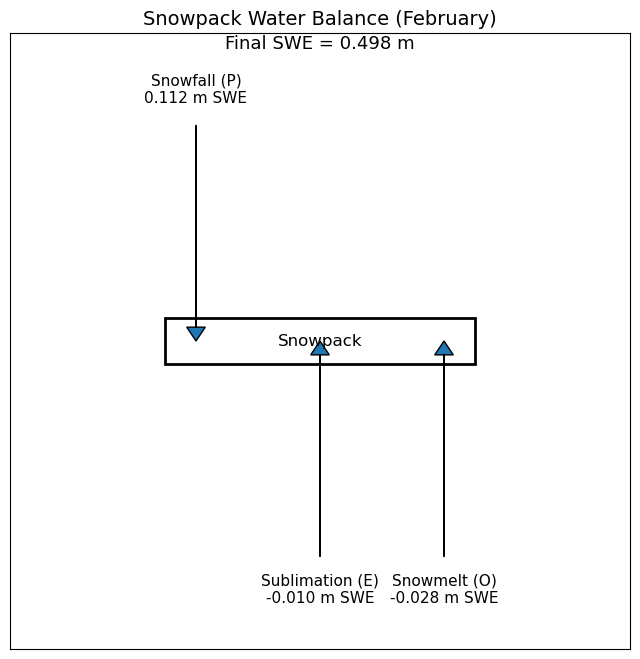

In [13]:
import matplotlib.pyplot as plt

# Flux values (meters SWE)
fluxes = {
    "Snowfall (P)": P,
    "Sublimation (E)": -abs(E_m),
    "Snowmelt (O)": -O
}

fig, ax = plt.subplots(figsize=(8,8))

# --------------------------------------------------
# Draw snowpack box
# --------------------------------------------------

box_width = 2
box_height = 0.6

snowpack = plt.Rectangle(
    (-box_width/2, -box_height/2),
    box_width,
    box_height,
    fill=False,
    linewidth=2
)

ax.add_patch(snowpack)

ax.text(0,0,"Snowpack",
        ha="center",
        va="center",
        fontsize=12)

# --------------------------------------------------
# Arrow positions
# --------------------------------------------------

positions = {
    "Snowfall (P)": -0.8,
    "Sublimation (E)": 0,
    "Snowmelt (O)": 0.8
}

max_flux = max(abs(v) for v in fluxes.values())
scale = 2.5 / max_flux

# --------------------------------------------------
# Draw arrows
# --------------------------------------------------

for label, value in fluxes.items():

    x = positions[label]
    length = value * scale

    if value > 0:
        # downward arrow (input)
        ax.arrow(
            x, 2.8,
            0, -2.8,
            head_width=0.12,
            length_includes_head=True
        )

        ax.text(
            x, 3.1,
            f"{label}\n{value:.3f} m SWE",
            ha="center",
            fontsize=11
        )

    else:
        # upward arrow (output)
        ax.arrow(
            x, -2.8,
            0, 2.8,
            head_width=0.12,
            length_includes_head=True
        )

        ax.text(
            x, -3.4,
            f"{label}\n{value:.3f} m SWE",
            ha="center",
            fontsize=11
        )

# --------------------------------------------------
# Final SWE label
# --------------------------------------------------

ax.text(
    0,
    3.8,
    f"Final SWE = {SWE_final:.3f} m",
    ha="center",
    fontsize=13
)

# --------------------------------------------------
# Formatting
# --------------------------------------------------

ax.set_xlim(-2,2)
ax.set_ylim(-4,4)

ax.set_xticks([])
ax.set_yticks([])

ax.set_title("Snowpack Water Balance (February)", fontsize=14)

plt.show()